LAURA NAVARRO MARTÍNEZ 

05/05/2026

f1_BE.py   

## FASE 1: SEMIEMPIRICAL MASS FORMULA 

From a real dataset of (N,Z), we've computed the synthetic data of the binding energies with the 
**semiempiric mass formula** and drawn the dependencies:

* -BE w Z for a isobaric chain (A cte). -> Mass parabola.
* N w Z -> Stability nuclear map/ Segré Plot 

In order to do so, we've found the SE coefficients from scratch.

In [2]:
# Imports.

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Functions.

# Data port.

def parse_ame2020(filepath: str) -> pd.DataFrame:
    """Parse the AME2020 mass table from a fixed-width text file.

    Extrapolated values (marked with '#') and uncalculable entries ('*')
    are silently skipped.

    Args:
        filepath (str): Path to the AME2020 table file (mass_1.mas20.txt).

    Returns:
        pd.DataFrame with columns:
            A              — mass number
            Z              — atomic number
            BE_per_A       — binding energy per nucleon (keV)
            Error_per_A    — experimental uncertainty on BE/A (keV)
            Mass_Excess    — atomic mass excess (keV)
            ME_Error       — experimental uncertainty on mass excess (keV)
            Element        — chemical symbol
    """
    data = []
    with open(filepath, "r") as f:
        lines = f.readlines()

    start_parsing = False
    for line in lines:
        if "0  1    1    0    1" in line:
            start_parsing = True
        if not start_parsing or len(line) < 80:
            continue

        try:
            A_str            = line[14:19]
            Z_str            = line[9:14]
            BE_per_A_str     = line[54:67]
            BE_per_A_err_str = line[68:78]
            ME_str           = line[29:43]
            ME_err_str       = line[43:55]
            element_symbol   = line[20:22].strip()

            # Skip extrapolated or missing entries
            if "#" in BE_per_A_str or "#" in BE_per_A_err_str or "*" in BE_per_A_str:
                continue
            if "#" in ME_str or "*" in ME_str:
                continue

            A            = int(A_str)
            Z            = int(Z_str)
            BE_per_A     = float(BE_per_A_str)
            BE_per_A_err = float(BE_per_A_err_str)
            ME           = float(ME_str)
            ME_err       = float(ME_err_str)

            data.append([A, Z, BE_per_A, BE_per_A_err, ME, ME_err, element_symbol])
        except ValueError:
            continue

    return pd.DataFrame(data, columns=[
        "A", "Z", "BE_per_A", "Error_per_A", "Mass_Excess", "ME_Error", "Element",
    ])

# Pairing term.

def pairing_term(Z,N):
    "(Z,N) arrays must be integer type when passed to pairing term."
    delta=np.zeros(len(Z)) # Row of zeros.
    even_even=(Z%2==0)&(N%2==0)
    odd_odd=(Z%2==1)&(N%2==1)
    delta[even_even]=1.0
    delta[odd_odd]=-1.0

    return delta.astype(np.float32)

# Plotting Mass Parabola.

def Draw_Mass_Parabola(Z_list,df,pairing_term):
    ""
    n=len(Z_list)
    ncols=2
    nrows=(n+ncols-1) // ncols  # ceiling division

    fig_all, axes = plt.subplots(nrows, ncols, figsize=(14,5*nrows))
    axes = axes.flatten()  # easier indexing

    for i, Z in enumerate(Z_list):
        subset=df.query("Z == @Z")

        if subset.empty:
            print(f"No data for Z={Z}, skipping.")
            continue

        A=np.array(subset["A"])
        Z_arr=np.array(subset["Z"])
        N=A-Z_arr
        delta=pairing_term(Z_arr.astype(int),N.astype(int))

        BE=(-1.0)*np.array(subset["BE_per_A"])  # keV / nucleon
        BE_calc=(-1.0)*np.array(( 15.21*A - 15.92*A**(2/3) - 0.68*( Z**2 / A**(1/3) ) - 
                  22.21*( (A-2*Z)**2 /A) + 10.67*delta/np.sqrt(A) ) * 10**3 / A) # keV / nucleon

        # --- Save individually ---
        fig_single, ax_single = plt.subplots(figsize=(10, 6))

        ax_single.scatter(A,BE,label="Actual Data",alpha=0.5,s=3,color="green")
        ax_single.plot(A,BE_calc,label="Semiempirical Mass Formula",color="blue",linewidth=0.75,linestyle='--')

        ax_single.set_title(f"- BE per nucleon vs Semiempirical Mass Formula  (Z={Z})")
        ax_single.set_xlabel("A", fontsize=12)
        ax_single.set_ylabel("- BE (keV)", fontsize=12)
        ax_single.legend()

        output_path = rf"C:\Users\Lauri\Desktop\TFG-code\results\figures\f1_BE_vs_SE_Z{Z}.pdf"
        fig_single.savefig(output_path,format='pdf',bbox_inches='tight')
        plt.close(fig_single)

        # --- Also draw into shared subplot grid ---
        ax=axes[i]
        ax.scatter(A,BE,label="Actual Data",alpha=0.5,s=3,color="green")
        ax.plot(A,BE_calc,label="Semiempirical Mass Formula",color="blue",linewidth=0.75,linestyle='--')
        ax.set_title(f"Z={Z}")
        ax.set_xlabel("A", fontsize=12)
        ax.set_ylabel("- BE (keV)", fontsize=12)
        ax.legend()

    # Hide any unused subplots (e.g. if n is odd)
    for j in range(i + 1, len(axes)):
        fig_all.axes[j].set_visible(False)

    fig_all.suptitle("- BE per nucleon vs Semiempirical Mass Formula", fontsize=14, y=1.01)
    fig_all.tight_layout()
    plt.show()
    
    return

In [4]:
# Load Dataset.

raw_df=parse_ame2020(r"C:\Users\Lauri\Desktop\TFG-code\data\mass_1.mas20.txt")

# Exclude very light nuclei (A < 16): shell efects important.
# Exclude inestable nuclei with BE very low or zero.
df=raw_df[((raw_df["A"]-raw_df["Z"])>=8)&(raw_df["Z"]>=8)]
df

,A,Z,BE_per_A,Error_per_A,Mass_Excess,ME_Error,Element
70,16,8,7976.2072,0.0002,-4737.00217,0.00030,O
76,17,8,7750.7291,0.0002,-808.76421,0.00064,O
77,17,9,7542.3284,0.0146,1951.70100,0.24800,F
83,18,8,7767.0981,0.0002,-782.81634,0.00064,O
84,18,9,7631.6383,0.0257,873.11200,0.46300,F
...,...,...,...,...,...,...,...
2545,265,108,7296.2474,0.0904,120900.24500,23.95800,Hs
2546,266,108,7298.2611,0.1019,121139.67500,27.10600,Hs
2547,266,109,7270.7598,0.3627,127672.68100,96.47300,Mt
2548,269,110,7250.1551,0.1167,134834.67100,31.40300,Ds


## 0. Coeficients for the Semiempirical Mass Formula

Remember:

$$B(A,Z)=a_V A-a_S A^{\frac{2}{3}}-a_C\frac{Z^2}{A^\frac{1}{3}}-a_A\frac{(A-2Z)^2}{A}+a_P\frac{\delta}{A^{1/2}}\quad ,$$

|Source| $a_V$ (MeV) | $a_S$ (MeV) | $a_C$ (MeV) | $a_A$ (MeV) | $a_P$ (MeV) |
|:-----:|:-----:|:-----:|:-----:|:-----:|:-----:|
|From Fernow| 15.8  | 18.3  | 0.70 | 23.2  | 11.2  |
|Our work| 15.54 | 16.94  | 0.70 | 23.02  | 12.50 |

Our work is based on the paper [Bethe–Weizsa¨cker semiempirical mass formula coefficients 2019
update based on AME2016](https://link.springer.com/article/10.1007/s41365-019-0718-8) with **least-squares adjustments method** on the AME2020 dataset of 2457 nulei (with the cut N,Z>8).


In [5]:
# Least-squares adjustment method procedure:

def pairing_delta_per_nuclei(Z,N):
    '''
    For each individual (Z,N) in dataset returns delta value.
    Implemented in `bw_basis`.
    '''
    if Z%2==0 and N%2==0:     
        return +1  # even-even
    elif Z%2!=0 and N%2!=0:   
        return -1  # odd-odd
    else:                             
        return  0  # odd-even

def bw_basis(A,Z):
    '''
    Bethe-Weiz. SEMF terms withut coefficients.
    Implemented in `build_system`.
    '''
    N=A-Z
    d=pairing_delta_per_nuclei(Z,N)
    return np.array([
        A,                          # volume term
        -A**(2/3),                   # surface term
        -Z**2 / A**(1/3),            # Coulomb term
        -(A - 2*Z)**2 / A,           # asymmetry term
        d / A**(1/2)                # pairing term
    ])

def build_system(nuclides):
    """
    Nuclides: list of (A, Z, B_exp) for each nuclei, where B_exp is total binding energy in MeV
    Returns matrix M and vector b such that M * coeffs = b.
    """
    M=np.zeros((5,5))
    b=np.zeros(5)

    for (A,Z,E_exp) in nuclides:
        phi=bw_basis(A, Z)           # shape (5,)
        M+=np.outer(phi, phi)      # 5x5 accumulation
        b+=phi*E_exp             # RHS accumulation

    for r in range(1, 6):
        delta_r = np.linalg.det(M[:r, :r])
        if delta_r<0:
            print(f"Δ_{r} = {delta_r:.4e} , M is not positive definite.")  # all should be > 0 to be positive definide
                                                                           # at a certain point (coeffs).

    return M,b

def bw_binding(A,Z,coeffs):
    return np.dot(bw_basis(A, Z),coeffs)

# Variables: (A,N,Z)

A=df['A']
Z=df['Z']
N=A-Z
BE=df['BE_per_A']*A*1e-3 # BE MeV !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

nuclides=list(zip(A,Z,BE))

M,b=build_system(nuclides)
coeffs=np.linalg.solve(M, b) # coeffs = [av, as, ac, aa, ap] MeV

BE_calc=np.array([bw_binding(A,Z,coeffs) for (A,Z,BE) in nuclides])

# -.-.-.-.-.-.-. Show the results -.-.-.-.-.-.-.

SEMF_1958={
    "a_V (volumen)"   : 15.835,   # coef. A
    "a_S (superficie)": 18.33,  # coef.  A^(2/3)
    "a_C (Coulomb)"   : 0.714,   # coef.  Z(Z-1)/A^(1/3)
    "a_A (simetría)"  : 23.2,    # coef.  (N-Z)^2/A
    "a_P (paridad)"   : 11.2,    # coef. delta/A^(1/2)
}

SEMF_1996={
    "a_V (volumen)"   :  16.24,
    "a_S (superficie)": 18.63,
    "a_C (Coulomb)"   :  '-',   # not reported
    "a_A (simetría)"  :  '-',   # not reported
    "a_P (paridad)"   :  '-',   # not reported
}

SEMF_2004={
    "a_V (volumen)"   :  15.77,
    "a_S (superficie)": 18.34,
    "a_C (Coulomb)"   : 0.71,
    "a_A (simetría)"  : 23.21,
    "a_P (paridad)"   :  12.00,
}

SEMF_2005={
    "a_V (volumen)"   :  15.78,
    "a_S (superficie)": 18.34,
    "a_C (Coulomb)"   : 0.71,
    "a_A (simetría)"  : 23.21,
    "a_P (paridad)"   :  12.00,
}

SEMF_2007={
    "a_V (volumen)"   :  15.36,
    "a_S (superficie)": 16.43,
    "a_C (Coulomb)"   : 0.69,
    "a_A (simetría)"  : 22.54,
    "a_P (paridad)"   :  '-',   # not reported.
}

SEMF_2018={
    "a_V (volumen)"   :  19.12,
    "a_S (superficie)": 18.19,
    "a_C (Coulomb)"   : 0.52,
    "a_A (simetría)"  : 12.54,
    "a_P (paridad)"   :  28.99,
}

# Paper work - 2019
SEMF_2019={
    "a_V (volumen)"   :  14.64,
    "a_S (superficie)": 14.08,
    "a_C (Coulomb)"   : 0.64,
    "a_A (simetría)"  : 21.07,
    "a_P (paridad)"   :  11.54,
}

# Our work 2026: coeficients SE (MeV)
SEMF_2026={
    "a_V (volumen)"   : coeffs[0],   # coef. A
    "a_S (superficie)": coeffs[1],  # coef.  A^(2/3)
    "a_C (Coulomb)"   : coeffs[2],   # coef.  Z(Z-1)/A^(1/3)
    "a_A (simetría)"  : coeffs[3],    # coef.  (N-Z)^2/A
    "a_P (paridad)"   : coeffs[4],    # coef. delta/A^(1/2)
}

SEMF_comparison={
    "Coeficient" : ['a_V','a_S','a_C','a_A','a_P'],
    "1958 (MeV)" : SEMF_1958.values(),
    "1996 (MeV)" : SEMF_1996.values(),
    "2004 (MeV)" : SEMF_2004.values(),
    "2005 (MeV)" : SEMF_2005.values(),
    "2007 (MeV)" : SEMF_2007.values(),
    "2018 (MeV)" : SEMF_2018.values(),
    "AME2016 - 2019 (MeV)" : SEMF_2019.values(),
    "AME2020 - 2026 (MeV)" : coeffs,
}

df_SEMF=pd.DataFrame(SEMF_comparison)
old=df_SEMF['AME2016 - 2019 (MeV)']
new=df_SEMF['AME2020 - 2026 (MeV)']
rel_err=np.abs(100.0*np.abs(new-old)/new)
SEMF_comparison['Relative Error (2026 - 2019) (%)']=rel_err

df_comparison=pd.DataFrame(SEMF_comparison)
df_comparison

,Coeficient,1958 (MeV),1996 (MeV),2004 (MeV),2005 (MeV),2007 (MeV),2018 (MeV),AME2016 - 2019 (MeV),AME2020 - 2026 (MeV),Relative Error (2026 - 2019) (%)
0,a_V,15.835,16.24,15.77,15.78,15.36,19.12,14.64,15.541430,5.800176
1,a_S,18.330,18.63,18.34,18.34,16.43,18.19,14.08,16.944424,16.904818
2,a_C,0.714,-,0.71,0.71,0.69,0.52,0.64,0.703300,9.000406
3,a_A,23.200,-,23.21,23.21,22.54,12.54,21.07,23.021352,8.476269
4,a_P,11.200,-,12.00,12.00,-,28.99,11.54,12.499760,7.678226


## 0. Magnitude of typical error in Nuclear physics

In [7]:
delta=pairing_term(Z.astype(int),N.astype(int))

BE_real=df["BE_per_A"]*10**(-3) # MeV / nucleon
Err_BE=df["Error_per_A"]*10**(-3) # MeV / nucleon
BE_calc=( 15.54*A - 16.94*A**(2/3) - 0.70*( Z**2 / A**(1/3) ) - 
         23.02*( (A-2*Z)**2 /A) + 12.50*delta/np.sqrt(A) )  / A # MeV / nucleon

nuclear_err=np.sqrt(np.mean((BE_real-BE_calc)**2)) # keV / nucleon
MABS=np.mean(np.abs(BE_real-BE_calc))
res_mag=np.mean(np.abs(BE_real-BE_calc))

sum=0.0
for n,Err in enumerate(BE_real):
    sum=sum+Err
    n=n+1

real_nuclear_err=sum/n

print(f"Root Mean Squared Error (RMSE) = %.3f MeV." %nuclear_err)
print(f"Mean Average Error (MAE) = %.3f MeV." %MABS)
print(f"Mean Average residual magnitude = %.3f MeV." %MABS)

Root Mean Squared Error (RMSE) = 0.047 MeV.
Mean Average Error (MAE) = 0.031 MeV.
Mean Average residual magnitude = 0.031 MeV.


## 0. Mass Parabola

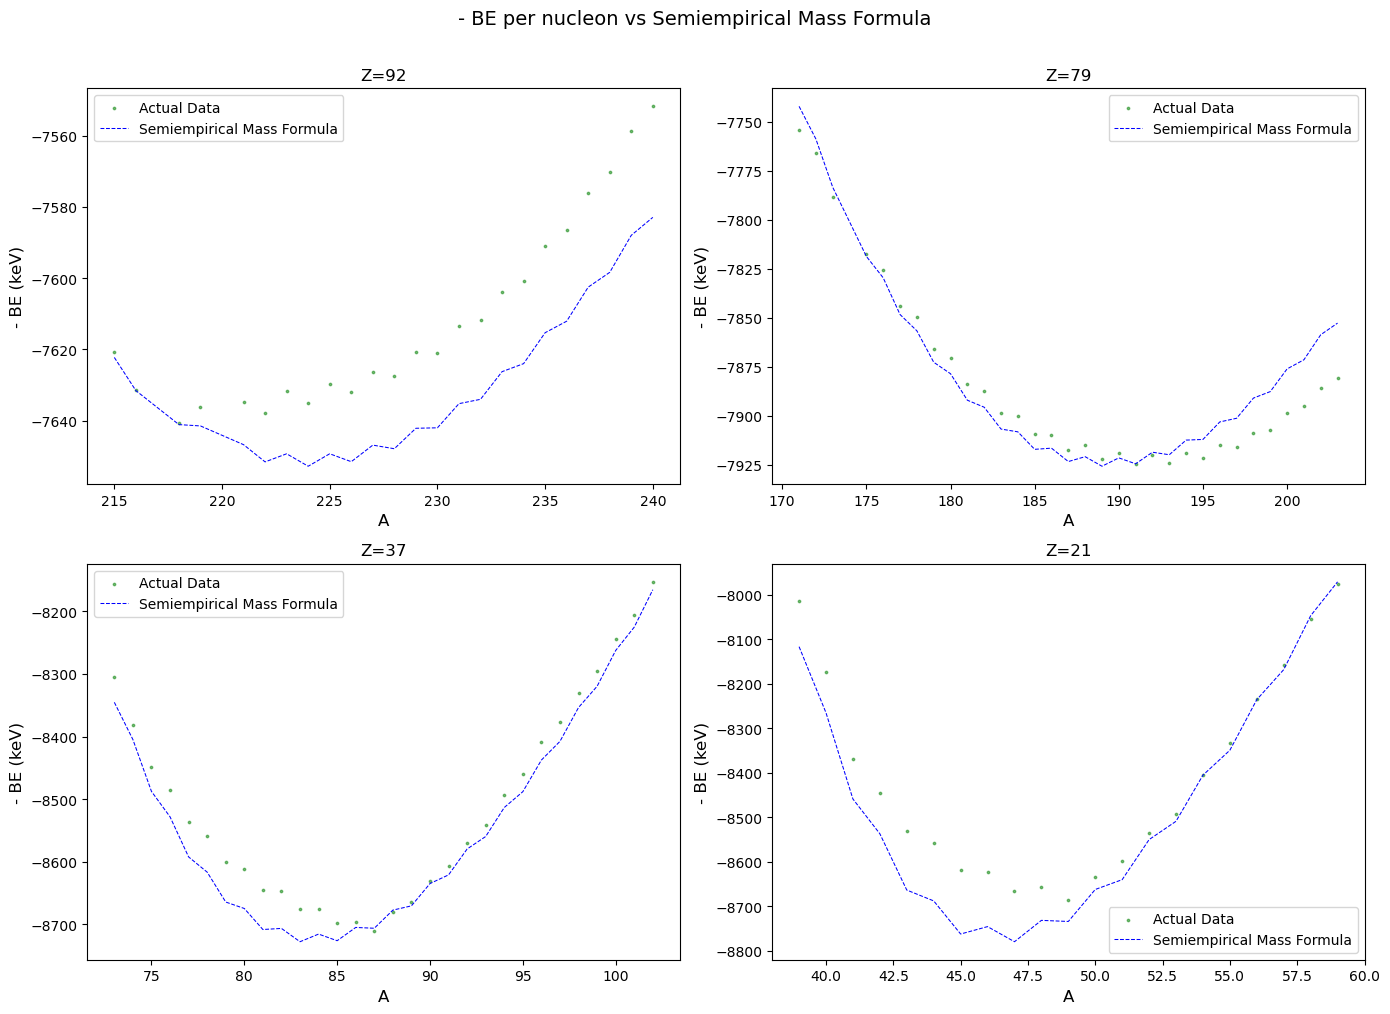

In [14]:
# Plotting Mass Parabola
    
#Z_list=[135, 120, 102, 80]
# Utp (Untripentium), Ubn (Unbinillium), No (Nobelium), Hg (Mercury)
Z_list=[92, 79, 37, 21]
# U (Uranium), Au (Gold), Rb (Rubidio), Ti (Titanium)
Draw_Mass_Parabola(Z_list,df,pairing_term)